# MLflow

MLflow is an open-source platform for managing the ML lifecycle — Tracking logs experiments, Models packages them portably, and the Registry handles versioning and deployment. It replaces the usual chaos of notebooks and scattered results with a single source of truth. Built by Databricks, it's now an industry standard across scikit-learn, PyTorch, and more.

## Setup


In [ ]:
#### Create Virtual Env

python -m venv mlflow-env

#### Activate venv
source mlflow-env/bin/activate

### Install packages

pip install mlflow  
pip install scikit-learn  
pip install pandas  
pip install matplotlib  
pip install jupyter  

### Start Jupyter notebook
jupyter notebook

### Verify mlflow
mlflow --version -> MLflow 3.x.x

### Start MLflow
mlflow ui -> http://localhost:5000

## Lession 1: MLflow Basics


### Module 1: Prepare Dataset

In [ ]:
# Load the iris dataset
from sklearn.datasets import load_iris


iris = load_iris()

print(iris.data.shape)

# Output: (150,4)

In [ ]:
# Create a DataFrame from the iris dataset
import pandas as pd

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

print(df.head())

### Module 2: Train/Test Split

In [ ]:
# We'll split it into 80/20 training/testing dataset. 
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Module 3: Create Model

In [ ]:
# Training a Random Forest Classifier model using the training data

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

In [ ]:
# Evaluating the model using the test data

predictions = model.predict(X_test)

In [ ]:
# Accuracy of the model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(accuracy)

# Output: 1.0

### Module 4: Your First MLflow Experiment

In [ ]:
# End any active MLflow run
import mlflow

mlflow.end_run()

In [ ]:
import mlflow

with mlflow.start_run():
    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    mlflow.log_metric("accuracy", accuracy)

#### Output
Navigate to http://127.0.0.1:5000/#/experiments/0 

Explore the run `rumbling-mule-912`

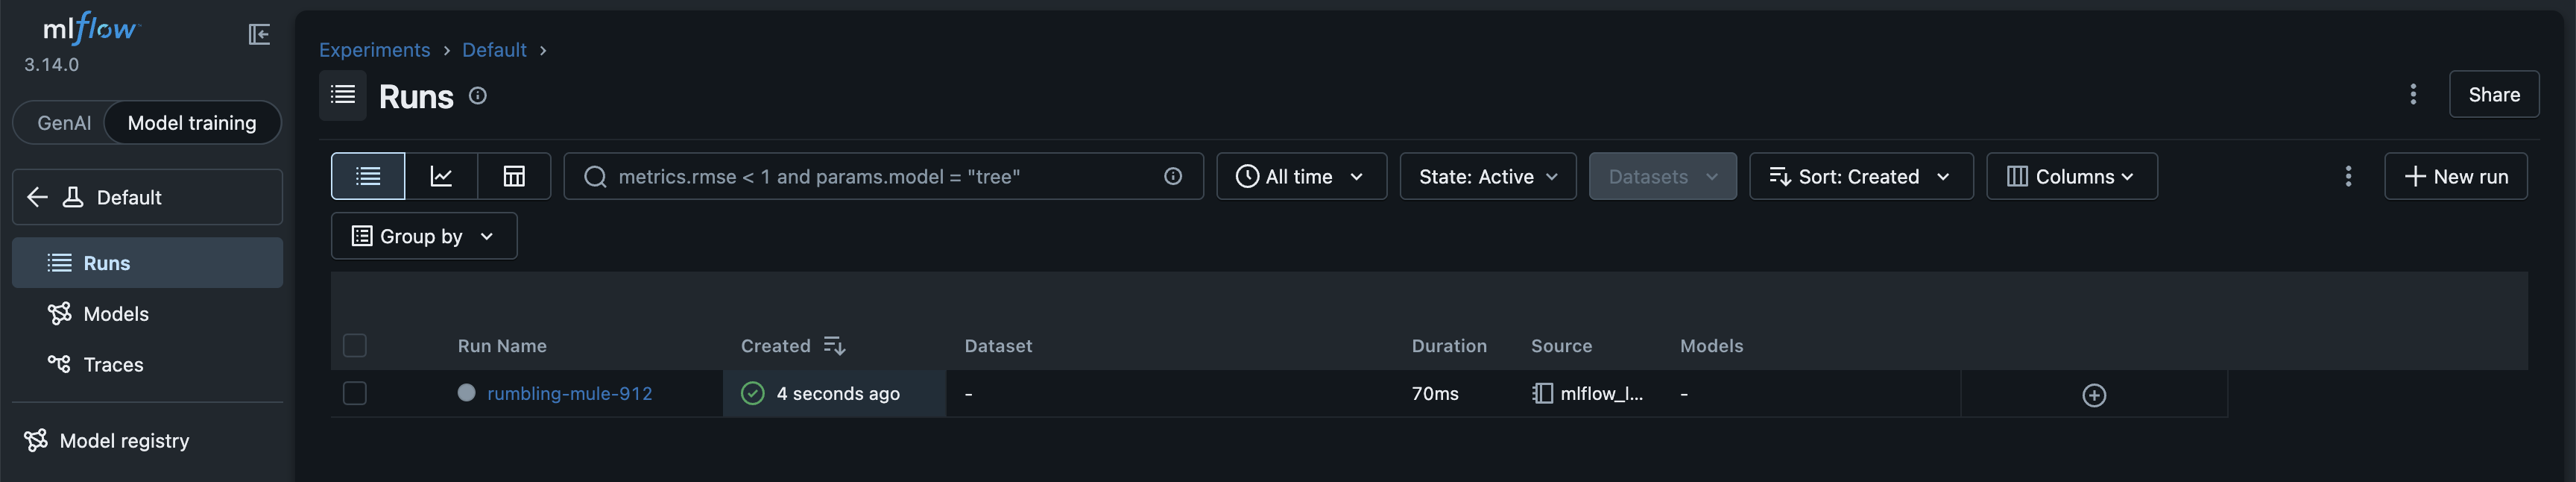

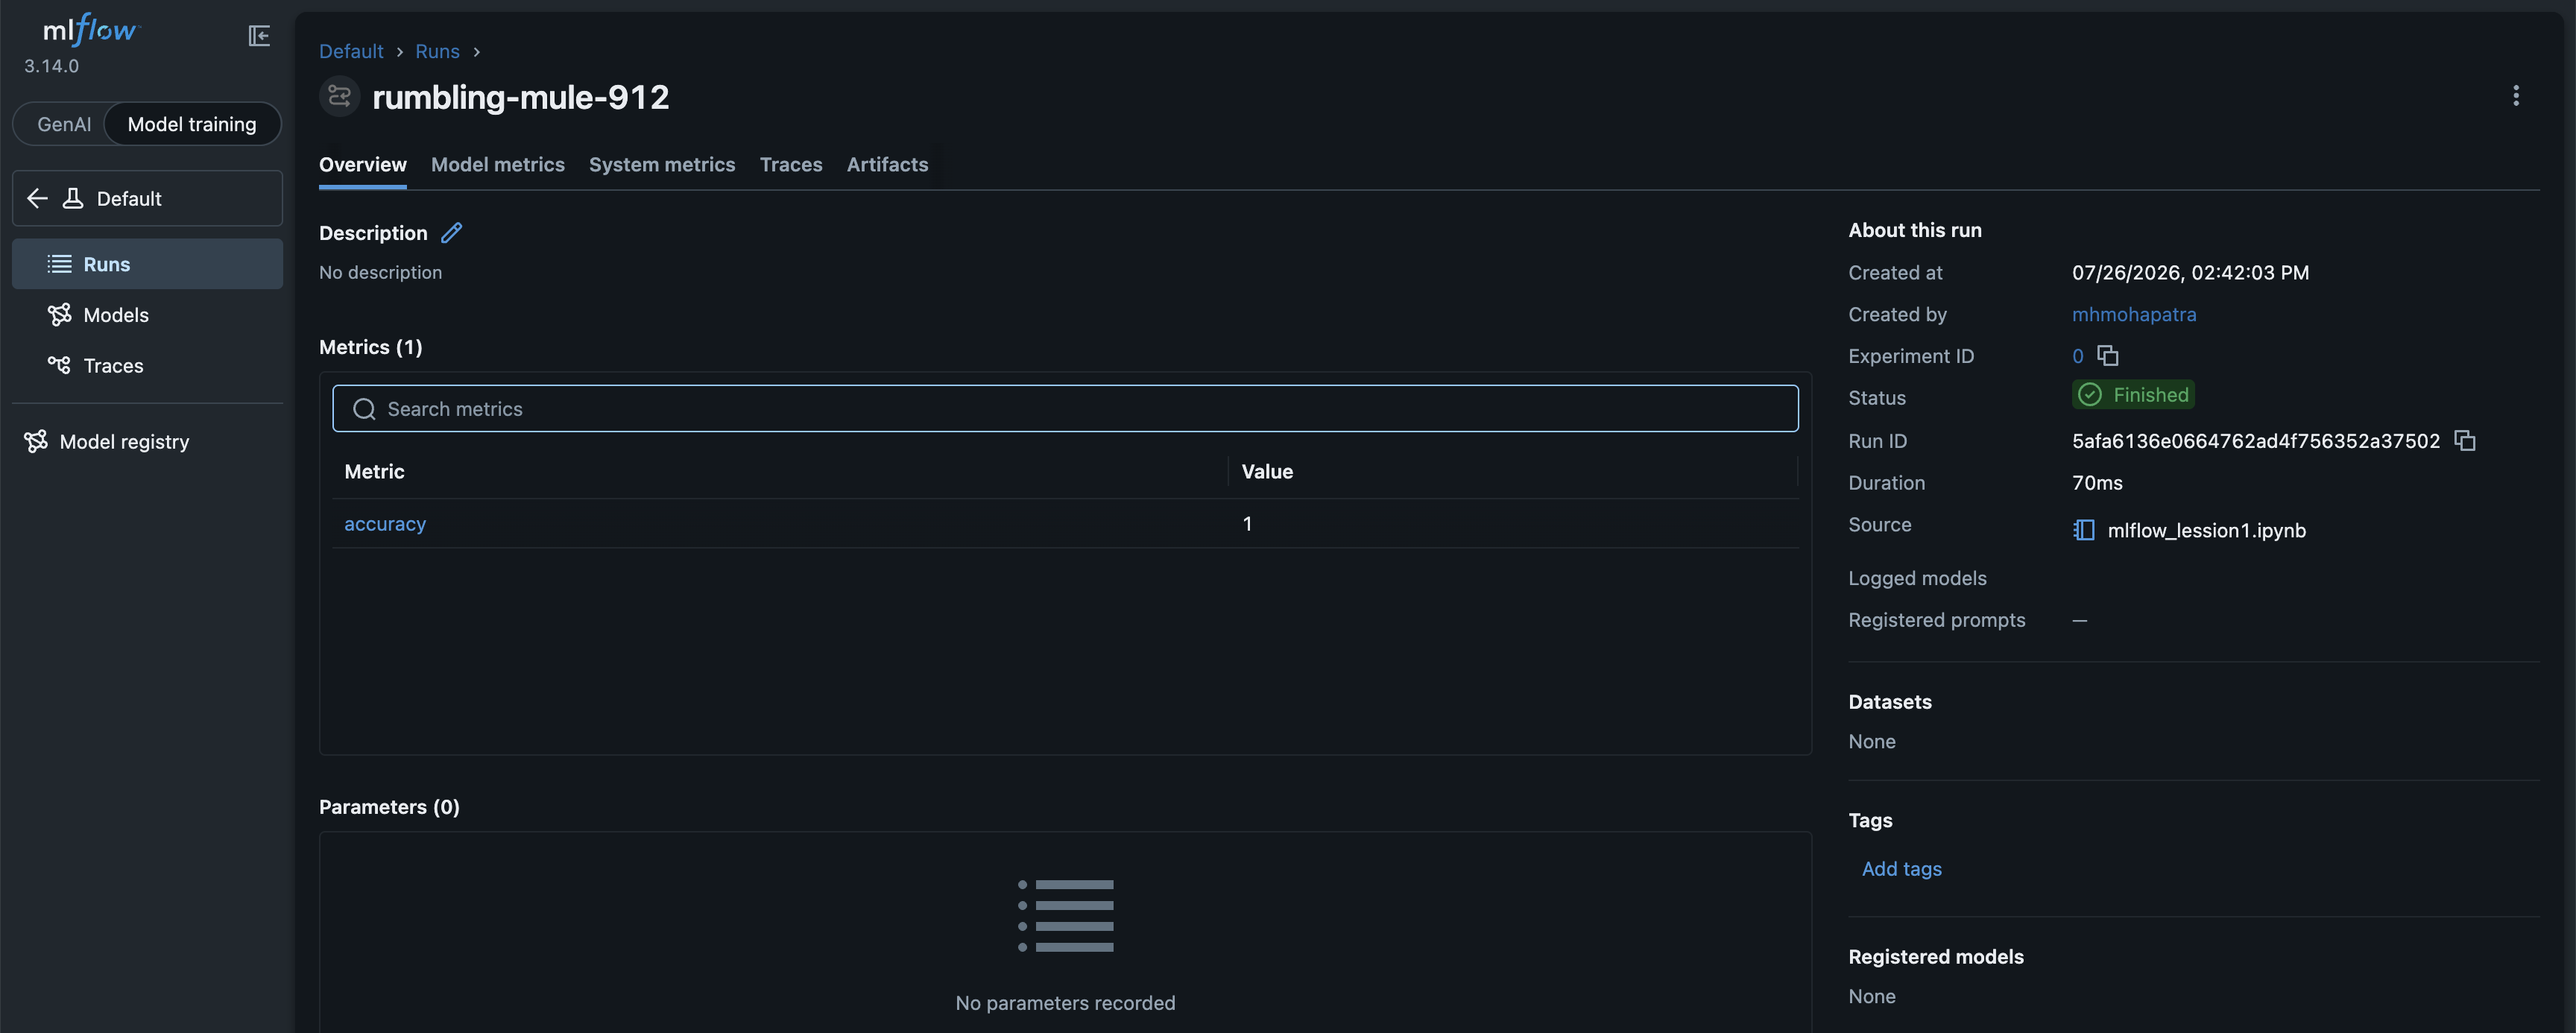

#### Log Parameters

We'll use a new model with a new run to show multiple runs in the same experiement.

In [ ]:
# Switching to a new run to log parameters and metrics

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5
)

# Logging parameters for the model
mlflow.log_param("n_estimators",100)
mlflow.log_param("max_depth",5)
mlflow.log_metric("accuracy", accuracy)


Explore the new run `orderly-grouse-946`

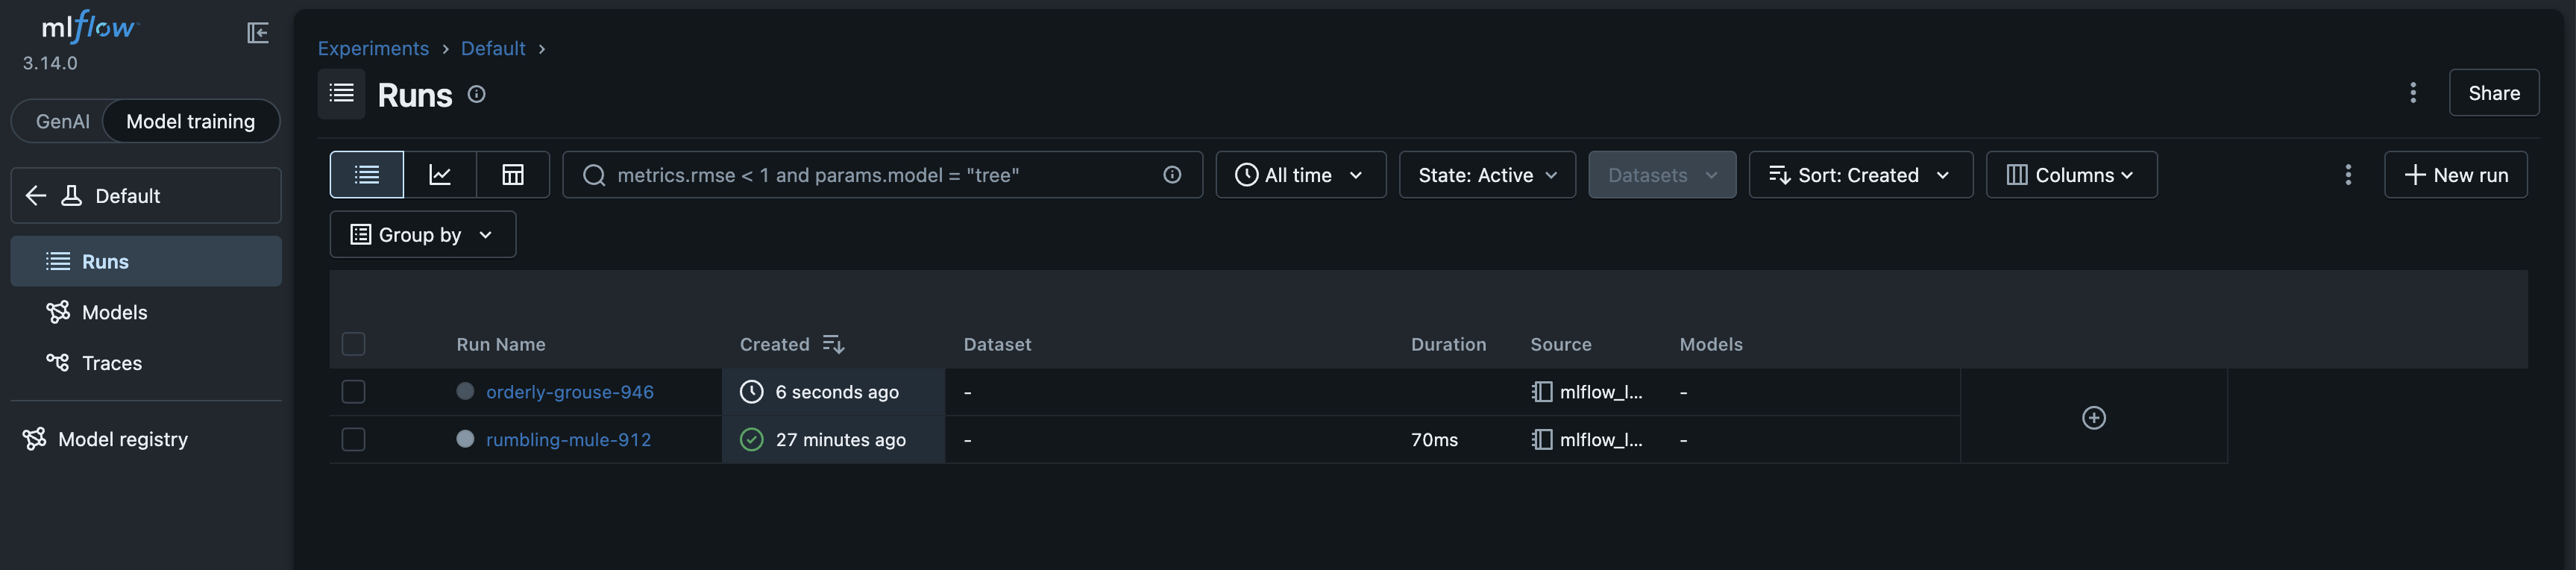

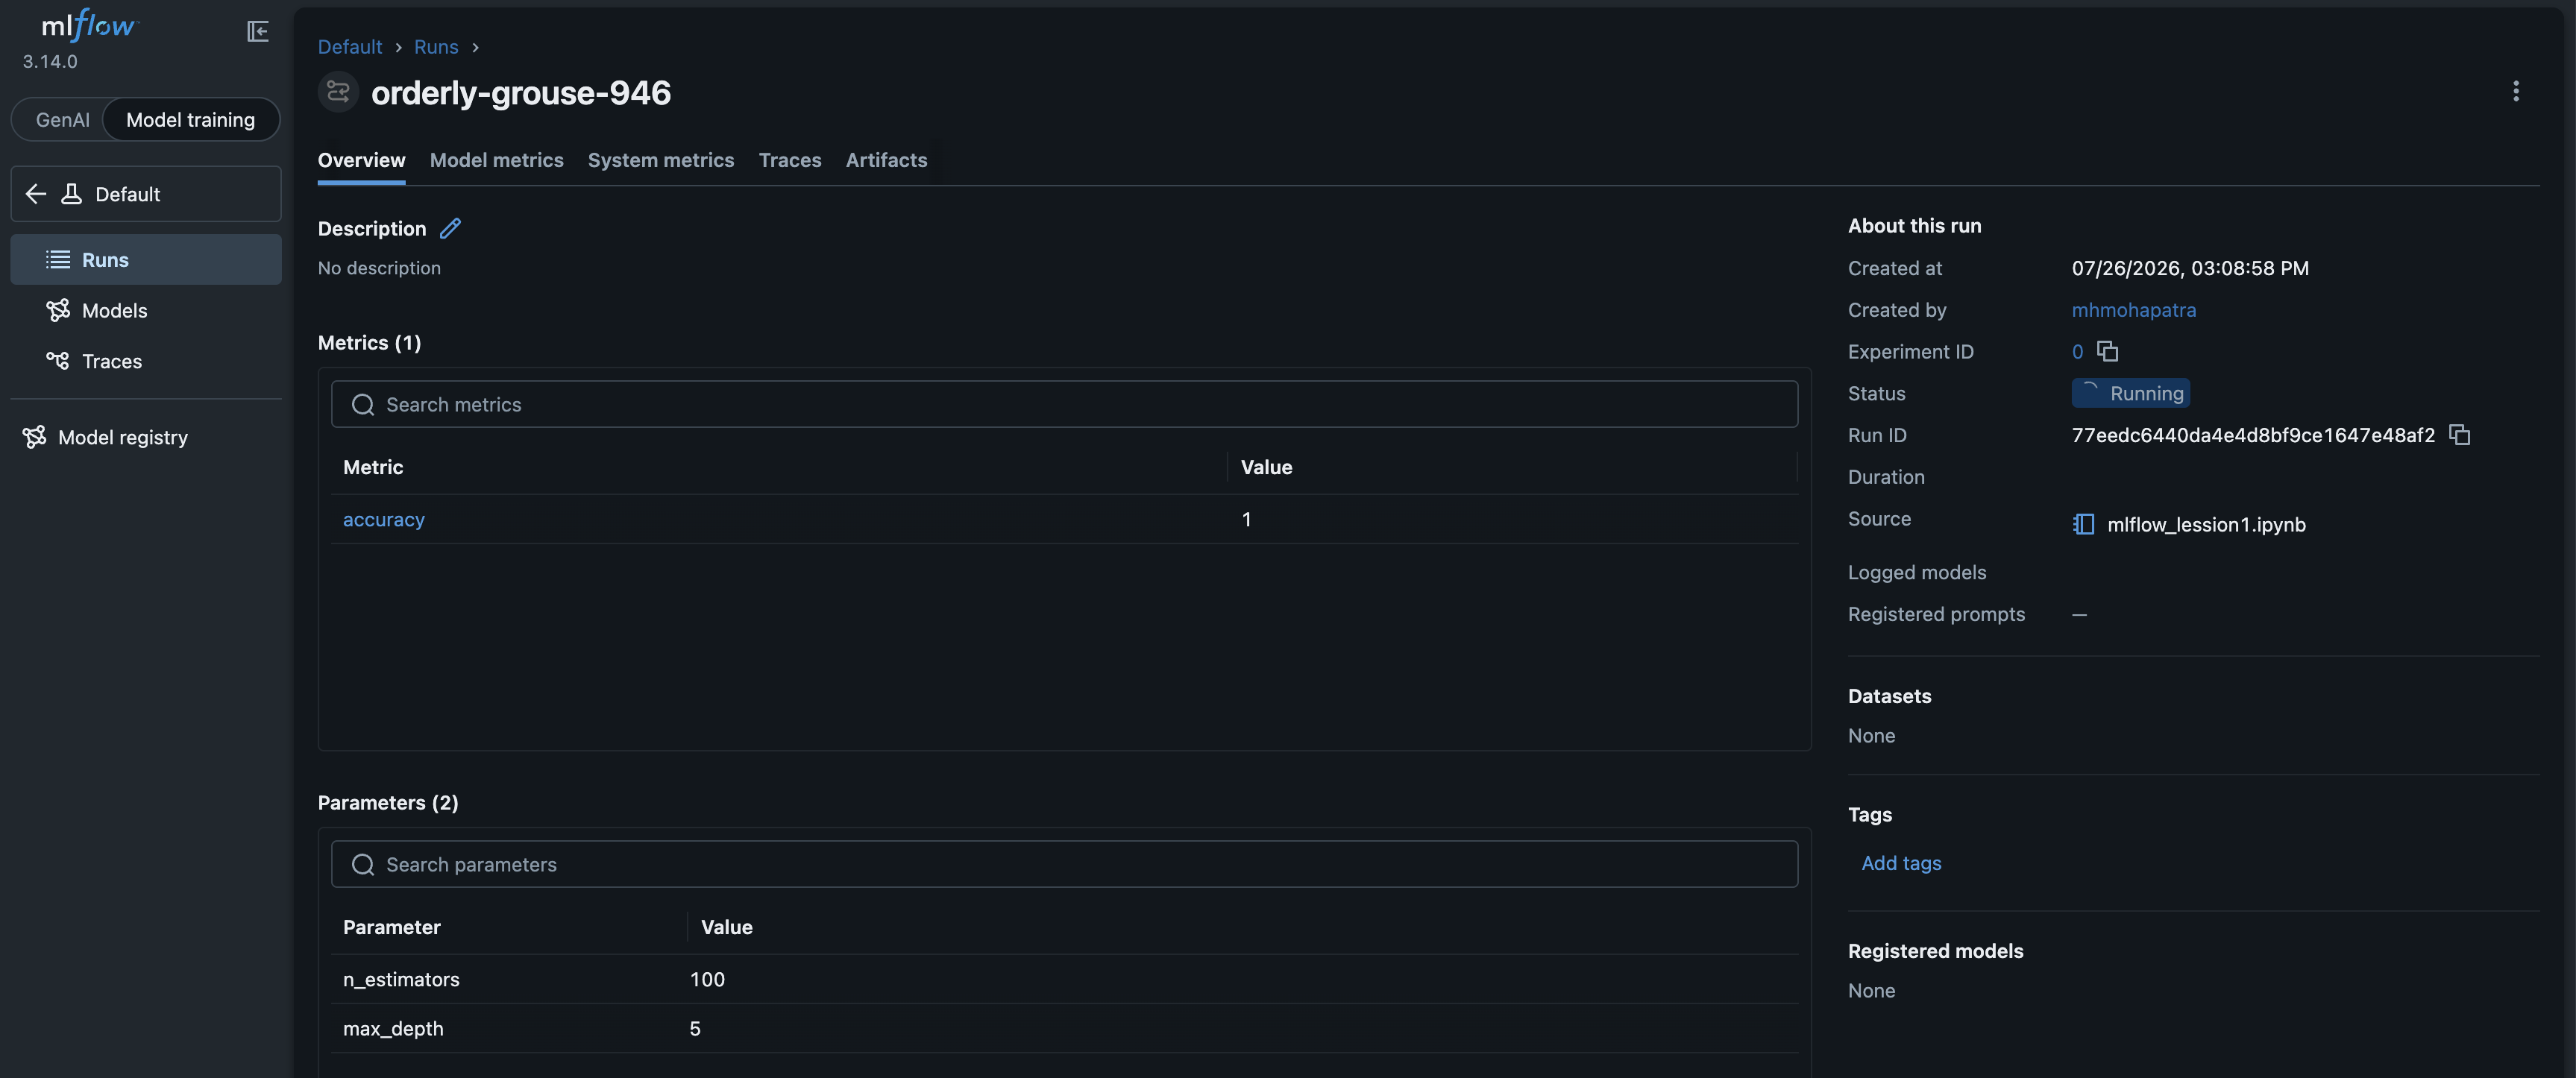

### Log Model

In [ ]:
# Logging the model using mlflow.sklearn

from pathlib import Path
import mlflow.sklearn

# Setting the tracking URI to the local MLflow server
mlflow.set_tracking_uri("http://127.0.0.1:5000/")


mlflow.sklearn.log_model(
    model,
    name="model",
)

### Log Dataset

In [ ]:
# Save the DataFrame
df.to_csv("iris.csv", index=False)

# Logging the dataset as an artifact
mlflow.log_artifact("iris.csv", artifact_path="data")

"iris.csv" is Under Artifacts Tab inside the `data` folder.

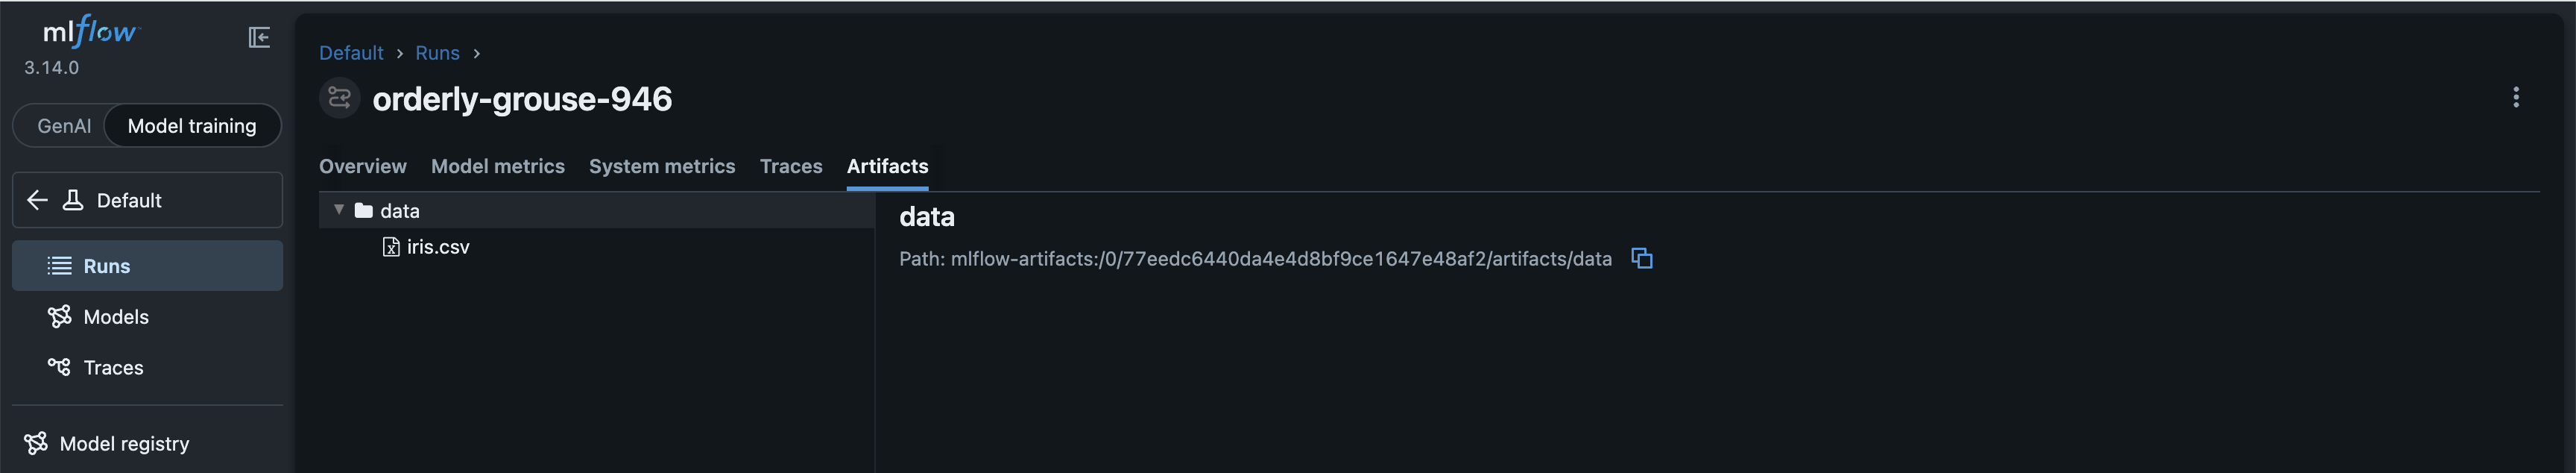

### Log Confusion Matrix

In [ ]:
# Visualizing the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

import matplotlib.pyplot as plt

plt.savefig("confusion_matrix.png")
plt.close()

# Log it
mlflow.log_artifact("confusion_matrix.png")

#### Now MLflow stores

In [ ]:
# accuracy  
# model  
# confusion_matrix  
# dataset  

### First Complete Training Script

In [ ]:
import mlflow
import mlflow.sklearn
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the iris dataset
iris = load_iris()

# Prepare the data
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["target"] = iris.target

# Split the data into training and testing sets
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



mlflow.set_tracking_uri("http://127.0.0.1:5000/")

with mlflow.start_run():

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    mlflow.log_param("trees",100)

    mlflow.log_param("depth",5)

    mlflow.log_metric("accuracy",acc)

    mlflow.sklearn.log_model(
        model,
        name="model",
    )

    # Save the DataFrame
    df.to_csv("iris.csv", index=False)

    # Logging the dataset as an artifact
    mlflow.log_artifact("iris.csv", artifact_path="data")

### Topic learned till now

## Lession 2: MLflow Advance
### <b> Experiment Tracking and Hyperparameter Tuning </b>

#### By the end of this lesson, you will be able to:

* Create and manage MLflow experiments, Create a Named Experiment.
* Execute multiple experiment runs with different hyperparameters.  
* Log parameters, metrics, and models using MLflow 3.14.  
* Compare experiment runs in the MLflow UI.  
* Search and filter runs programmatically.  
* Identify and load the best-performing model.  

### <b> Module 1: Create a Named Experiment </b>

In [ ]:
import mlflow

mlflow.set_experiment("RandomForest Iris Classification")

#### Understanding an experiment

##### Think of an experiment as a folder with multiple runs.

Each Run stores:
* Parameters
* Metrics
* Artifacts
* Model
* Dataset
* Tags
* Execution time

#### Running experiment for hyperparameter variation

One of the prime use case of MLflow is to run the model for different hyperparameter configuration and finding the best model.

For the following model, we will vary two hyperparameters and find the best model.

##### Let's create a hyper parameter grid for two hyperparameters which will will vary and run the experiment on.

trees = [1, 2, 50, 1000]  
depths = [1, 4, 100]

#### Loop Through All Models

In [ ]:
import mlflow
import mlflow.sklearn
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the iris dataset
iris = load_iris()

# Prepare the data
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["target"] = iris.target

# Split the data into training and testing sets
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

mlflow.set_tracking_uri("http://127.0.0.1:5000/")
trees = [1, 2, 50, 1000]
depths = [1, 4, 100]

# Set the experiment name
mlflow.set_experiment("RandomForest Iris Classification Experiment")

# Train models with different hyperparameters
# Loop through trees
for tree in trees:
    # Loop through depths
    for depth in depths:
        with mlflow.start_run():
            # Create model for each combination of hyperparameters
            model = RandomForestClassifier(
                n_estimators=tree,
                max_depth=depth,
                random_state=42
            )
            # Train the model
            model.fit(X_train, y_train)
            # Evaluate the model
            predictions = model.predict(X_test)
            # Calculate accuracy
            accuracy = accuracy_score(
                y_test,
                predictions
            )
            # Log estimator and depth as parameters
            mlflow.log_param("n_estimators", tree)  
            mlflow.log_param("max_depth", depth)

            # Log accuracy as a metric
            mlflow.log_metric("accuracy", accuracy)

            # Log the model and save the returned ModelInfo object
            model_info = mlflow.sklearn.log_model(model, name = "model")

#### Stop Here and Explore

For each run, inspect: Parameters, Metrics, Logged model, Start time, Duration.

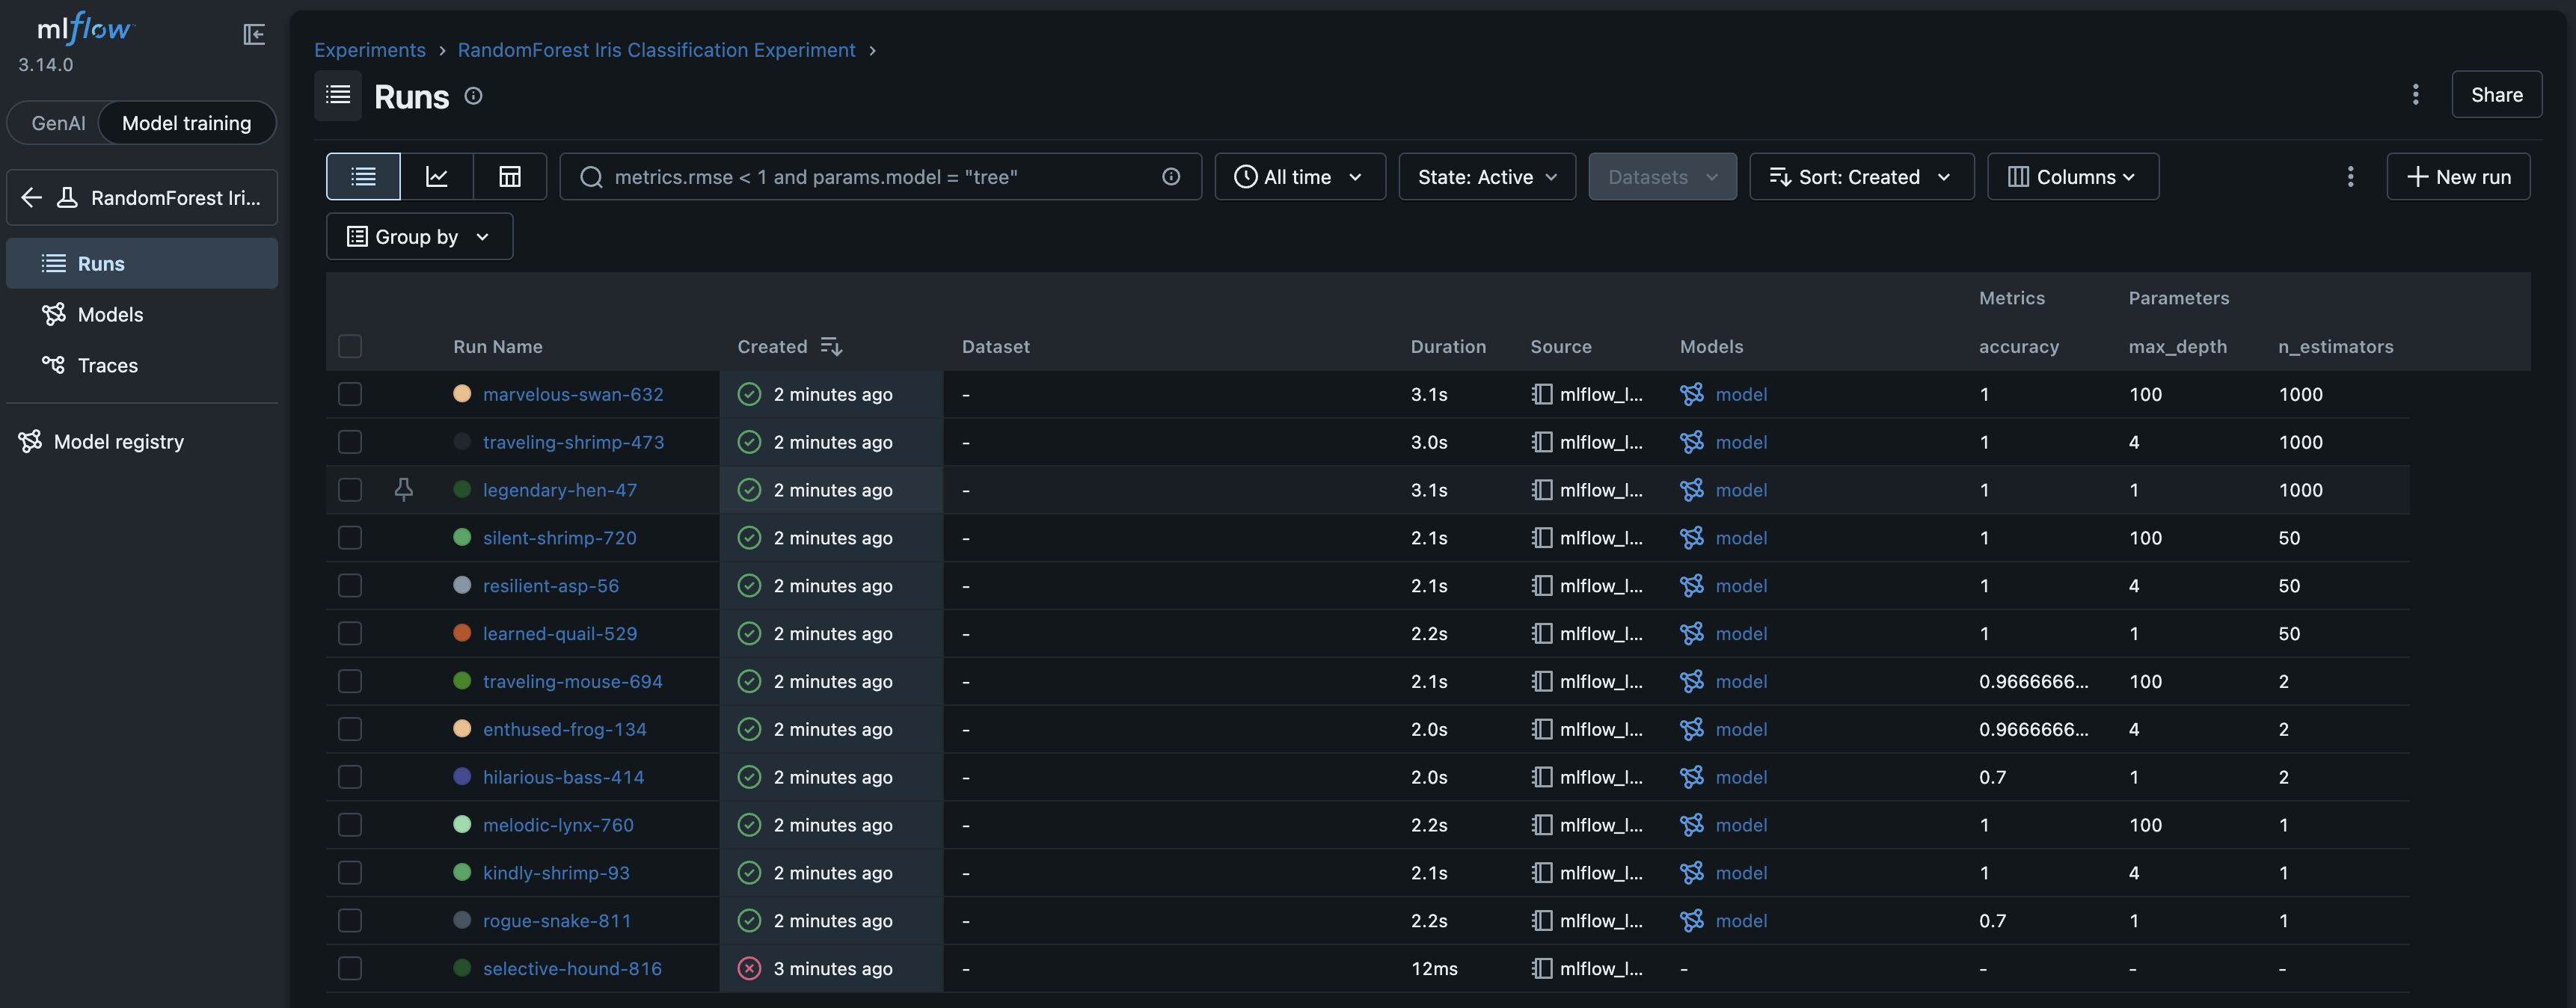

You'll start seeing how MLflow organizes experiments.

<b>At this stage, you can sort on accuracy to find the best model.</b>

### <b> Module 2: Loading the Best Model from MLflow </b>

#### <b> Approach 1: </b> Same session (Recommended During Training) using the model info object from the log model call.

In [18]:
# Load the model directly using the URI returned by log_model()
loaded_model = mlflow.sklearn.load_model(model_info.model_uri)

# Run inference
predictions = loaded_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 1.0


#### <b> Approach 2: </b> Find and Load the Best Model Later (Production Style)

##### <b> Find the Best Run </b>

In [21]:
# Get the experiment
experiment = mlflow.get_experiment_by_name("RandomForest Iris Classification Experiment")

# Retrieve all runs for the experiment
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

# Select the run with the highest accuracy
best_run = runs.sort_values(
    by="metrics.accuracy",
    ascending=False
).iloc[0]

# Build the model URI for the logged model
model_uri = f"runs:/{best_run.run_id}/model"

print("Best Accuracy :", best_run["metrics.accuracy"])
print("Model URI     :", model_uri)

Best Accuracy : 1.0
Model URI     : runs:/a19ea85f9cc0438f8c70a0383430295d/model


##### <b> Load the Best Model </b>

In [22]:
# Load the best model from MLflow
best_model = mlflow.sklearn.load_model(model_uri)

# Run inference
predictions = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 1.0
